In [6]:
import ssms
from matplotlib import pyplot as plt
from ssms.basic_simulators import simulator
import numpy as np
import pickle as pkl 

In [8]:
combined_data = "/users/azhan378/data/azhang/efficient_fpt_data/simulated_data/addm_data_all_eta_20260206-174356.pkl"
with open(combined_data, "rb") as f:
    data = pkl.load(f)
data_keys = sorted(data.keys())
print(data_keys)

[0.0, 0.05, 0.1, 0.15000000000000002, 0.2, 0.25, 0.30000000000000004, 0.35000000000000003, 0.4, 0.45, 0.5, 0.55, 0.6000000000000001, 0.65, 0.7000000000000001, 0.75, 0.8, 0.8500000000000001, 0.9, 0.9500000000000001, 1.0]


/tmp/ipykernel_975022/2029889944.py:3: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data = pkl.load(f)


In [24]:
eta_data_025 = data[0.25]
decision_data = eta_data_025['decision_data']
decision_data[:, 0]

array([6.058335, 1.705495, 0.372745, ..., 1.692795, 4.211195, 4.864595],
      shape=(30000,))

In [9]:
# list(ssms.config.model_config.keys())

In [12]:
from ssms import Simulator 

addm = Simulator("addm_constant")
addm_out = addm.simulate(theta={"eta": 0.25, "kappa": 0.5, "a": 2, "z": 0.5, "t": 0.0},
                        n_samples=30000)

In [26]:
addm_out['rts']

array([[1.2378851],
       [1.9453136],
       [1.6389247],
       ...,
       [3.5409029],
       [2.526283 ],
       [2.9946816]], shape=(30000, 1), dtype=float32)

Text(0, 0.5, 'Density')

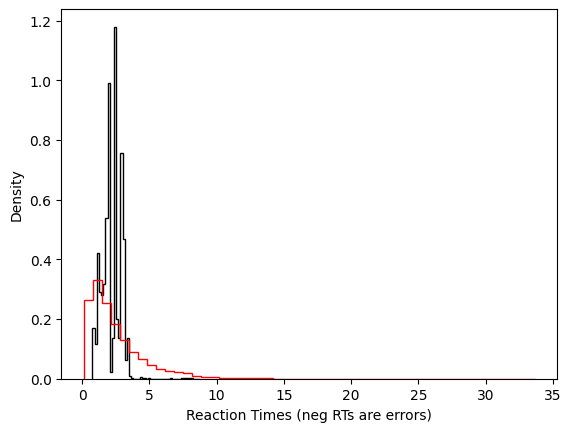

In [25]:
plt.hist(
    addm_out["rts"][addm_out["rts"] != -999],
    bins=50,
    histtype="step",
    color="black",
    label="Weibull Deadline",
    density=True,
)
plt.hist(
    decision_data[:,0],
    bins=50,
    histtype="step",
    color="red",
    label="ADDm with eta=0.25",
    density=True,
)
plt.xlabel("Reaction Times (neg RTs are errors)")
plt.ylabel("Density")